# Chapter 2 Learning File

# Core Notebook Setup

## Environment and Imports

In [1]:
# ══════════════════════════════════════════════════════
# Environment Setup
# ══════════════════════════════════════════════════════

# ── Standard Library ──────────────────────────────────
import os
import sys
import warnings

# ── Data ──────────────────────────────────────────────
import numpy as np
import pandas as pd

# ── Visualisation ─────────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter

# ── Machine Learning ──────────────────────────────────
from sklearn.exceptions import ConvergenceWarning
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# ── Jupyter ───────────────────────────────────────────
from IPython.core.interactiveshell import InteractiveShell
from IPython.display import display

# ── Custom Utilities ──────────────────────────────────
def find_repo_root(start, repo_name='CreditRiskLearning'):
    path = os.path.abspath(start)
    while True:
        if os.path.basename(path) == repo_name:
            return path
        parent = os.path.dirname(path)
        if parent == path:  # hit filesystem root
            raise FileNotFoundError(f"Could not find repo root: {repo_name}")
        path = parent

repo_root = find_repo_root(os.getcwd())
sys.path.append(os.path.join(repo_root, 'Core Resources'))
import python_style_util as psu

# ══════════════════════════════════════════════════════
# Display Settings
# ══════════════════════════════════════════════════════

%matplotlib inline

# Pandas
pd.set_option('display.float_format', '{:.2f}'.format)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', None)
pd.set_option('display.colheader_justify', 'left')

# NumPy
np.set_printoptions(precision=4, suppress=True, linewidth=120)

# Jupyter
InteractiveShell.ast_node_interactivity = 'all'

# Style
psu.set_style()

## Cache Clearing

In [2]:
import matplotlib as mpl
import shutil

cache_dir = mpl.get_cachedir()
print(f'Cache location: {cache_dir}')
shutil.rmtree(cache_dir)
print('Cache cleared')

Cache location: C:\Users\evanr\.matplotlib
Cache cleared


## Display Setttings

In [3]:

# Pandas Display Options

pd.set_option('display.float_format', '{:.2f}'.format)  # 2 decimal places on floats
pd.set_option('display.max_columns', None)               # show all columns
pd.set_option('display.max_rows', 100)                   # show up to 100 rows
pd.set_option('display.width', None)                     # don't wrap wide dataframes
pd.set_option('display.colheader_justify', 'left')       # left-align column headers
pd.set_option('display.precision', 4)                    # decimal precision for describe()
pd.set_option('display.large_repr', 'truncate')          # truncate instead of summary for large dfs

# Numpy Display Options

pd.set_option('display.float_format', '{:.2f}'.format)  # 2 decimal places on floats
pd.set_option('display.max_columns', None)               # show all columns
pd.set_option('display.max_rows', 100)                   # show up to 100 rows
pd.set_option('display.width', None)                     # don't wrap wide dataframes
pd.set_option('display.colheader_justify', 'left')       # left-align column headers
pd.set_option('display.precision', 4)                    # decimal precision for describe()
pd.set_option('display.large_repr', 'truncate')          # truncate instead of summary for large dfs

# Matplotlib Display Options

plt.rcParams['figure.dpi'] = 120          # sharper figures
plt.rcParams['savefig.dpi'] = 150         # higher res when saving
plt.rcParams['savefig.bbox'] = 'tight'    # no clipped labels when saving
plt.rcParams['savefig.facecolor'] = 'white'  # white background on saved figures

# Warnings Options

warnings.filterwarnings('ignore')          # suppress all warnings

# or more selectively:

warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)
warnings.filterwarnings('ignore', category=ConvergenceWarning)

# Jupyter Notebooks display


InteractiveShell.ast_node_interactivity = 'all'  # print every expression not just last one



## Data Types and Missing Values


**Dataset:** German Credit Dataset — UCI 1994  
**Author:** Chuch  
**Date:** 12-06-2026  
**Objective:** Exploring more libraries and methods for data types and handling missing values  
**Status:** In Progress

## Data Loading

In [4]:
columns = [
    'checking_status', 'duration', 'credit_history', 'purpose', 'credit_amount',
    'savings', 'employment', 'installment_rate', 'personal_status', 'other_debtors',
    'residence_since', 'property', 'age', 'other_installments', 'housing',
    'existing_credits', 'job', 'dependents', 'telephone', 'foreign_worker', 'target'
]


In [5]:
# Build path relative to notebook location
base_path = os.path.dirname(os.path.abspath('data types and missing values.ipynb'))
data_path = os.path.join(base_path, 'German Credit Data', 'german.data')

# Load data
df = pd.read_csv('../../../German Credit Data/german.data', sep=' ', header=None, names=columns)

In [6]:
os.getcwd()

'c:\\Users\\evanr\\OneDrive\\Desktop\\CreditRiskLearning\\Learning Journey\\Theory and Stats\\02. Data Types + Missing Values'

## Regex Mapping Categories to Text

In [7]:
import re

doc_path = os.path.join(repo_root, 'German Credit Data', 'german.doc')

def load_german_credit_mappings(filepath):
    """
    Reads the German Credit dataset documentation and returns
    a dictionary mapping category codes to their descriptions.
    e.g. {'A11': '< 0 DM', 'A12': '0 <= ... < 200 DM', ...}
    """
    
    # Read the raw text file
    with open(filepath, 'r') as f:
        text = f.read()
    
    # Define the regex pattern
    # [A-Z]  = one uppercase letter (A, B, C, D etc.)
    # \d{2}  = exactly two digits
    # \s*:\s* = colon with optional surrounding whitespace
    # (.+)   = one or more characters (the description)
    pattern = r'([A-Z]\d{2})\s*:\s*(.+)'
    
    # re.findall returns a list of tuples [(code, description), ...]
    matches = re.findall(pattern, text)
    
    # Convert list of tuples into a dictionary
    # .strip() cleans up any trailing whitespace from descriptions
    mapping = {code: description.strip() for code, description in matches}
    
    return mapping


# Usage
mappings = load_german_credit_mappings(doc_path)

print(df['checking_status'].map(mappings).unique())


<StringArray>
['... <    0 DM', '0 <= ... <  200 DM', 'no checking account',
 '... >= 200 DM /']
Length: 4, dtype: str


## Quick Audit

In [8]:
# ── Data Audit ────────────────────────────────────────
print(df.dtypes)
print('\nMissing values:')
print(df.isnull().sum())
print('\nShape:', df.shape)

checking_status         str
duration              int64
credit_history          str
purpose                 str
credit_amount         int64
savings                 str
employment              str
installment_rate      int64
personal_status         str
other_debtors           str
residence_since       int64
property                str
age                   int64
other_installments      str
housing                 str
existing_credits      int64
job                     str
dependents            int64
telephone               str
foreign_worker          str
target                int64
dtype: object

Missing values:
checking_status       0
duration              0
credit_history        0
purpose               0
credit_amount         0
savings               0
employment            0
installment_rate      0
personal_status       0
other_debtors         0
residence_since       0
property              0
age                   0
other_installments    0
housing               0
existing_credits     

# Project Body

## Part 1: Data Types

### Continuous Data

Numerical data that can take any value within a range, including decimals. There is no meaningful gap between possible values. In credit risk: income ($67,432.50), loan amount, interest rate, LVR. These variables are modelled differently from counts or categories.

print(df.select_dtypes(include='number').describe())

### Discrete Data

Numerical data that can only take specific values, often integers. There are meaningful gaps between possible values. In credit risk: number of previous defaults, number of credit lines, number of late payments. These variables are often modelled as counts or categories.

In [9]:
df.head(5)

,checking_status,duration,credit_history,purpose,credit_amount,savings,employment,installment_rate,personal_status,other_debtors,residence_since,property,age,other_installments,housing,existing_credits,job,dependents,telephone,foreign_worker,target
0,A11,6,A34,A43,1169,A65,A75,4,A93,A101,4,A121,67,A143,A152,2,A173,1,A192,A201,1
1,A12,48,A32,A43,5951,A61,A73,2,A92,A101,2,A121,22,A143,A152,1,A173,1,A191,A201,2
2,A14,12,A34,A46,2096,A61,A74,2,A93,A101,3,A121,49,A143,A152,1,A172,2,A191,A201,1
3,A11,42,A32,A42,7882,A61,A74,2,A93,A103,4,A122,45,A143,A153,1,A173,2,A191,A201,1
4,A11,24,A33,A40,4870,A61,A73,3,A93,A101,4,A124,53,A143,A153,2,A173,2,A191,A201,2


In [10]:
print(df['credit_amount'].value_counts().sort_index())

credit_amount
250      1
276      1
338      1
339      1
343      1
        ..
15653    1
15672    1
15857    1
15945    1
18424    1
Name: count, Length: 921, dtype: int64


### Categorical Data

Data that represents distinct groups or categories. In credit risk: credit history (good, bad, unknown), purpose of loan (car, education, home improvement), employment status (employed, unemployed, self-employed). These variables are often modelled using one-hot encoding or label encoding.

Below is the method for taking categoirical variables and converting them to numerical format using one-hot encoding. This is a common preprocessing step before feeding the data into machine learning models, as most models require numerical input.


In [11]:
# See all categories in a column

print(columns)

# Find all columns that I actually want to encode - all with categories NOT continuous values

print(df.select_dtypes(include='object').columns.tolist())

cat_cols = df.select_dtypes(include='object').columns.tolist()

df_encoded = pd.get_dummies(df, columns=cat_cols, drop_first=True)
                        
# Show just the new checking_status columns
print(df_encoded.filter(like='checking_status').astype(int).head(1000))

df_encoded.astype(int).head(5)

['checking_status', 'duration', 'credit_history', 'purpose', 'credit_amount', 'savings', 'employment', 'installment_rate', 'personal_status', 'other_debtors', 'residence_since', 'property', 'age', 'other_installments', 'housing', 'existing_credits', 'job', 'dependents', 'telephone', 'foreign_worker', 'target']
['checking_status', 'credit_history', 'purpose', 'savings', 'employment', 'personal_status', 'other_debtors', 'property', 'other_installments', 'housing', 'job', 'telephone', 'foreign_worker']
     checking_status_A12  checking_status_A13  checking_status_A14
0    0                    0                    0                  
1    1                    0                    0                  
2    0                    0                    1                  
3    0                    0                    0                  
4    0                    0                    0                  
..                   ...                  ...                  ...
995  0                    

,duration,credit_amount,installment_rate,residence_since,age,existing_credits,dependents,target,checking_status_A12,checking_status_A13,checking_status_A14,credit_history_A31,credit_history_A32,credit_history_A33,credit_history_A34,purpose_A41,purpose_A410,purpose_A42,purpose_A43,purpose_A44,purpose_A45,purpose_A46,purpose_A48,purpose_A49,savings_A62,savings_A63,savings_A64,savings_A65,employment_A72,employment_A73,employment_A74,employment_A75,personal_status_A92,personal_status_A93,personal_status_A94,other_debtors_A102,other_debtors_A103,property_A122,property_A123,property_A124,other_installments_A142,other_installments_A143,housing_A152,housing_A153,job_A172,job_A173,job_A174,telephone_A192,foreign_worker_A202
0,6,1169,4,4,67,2,1,1,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,1,0,1,0,0,0,0,0,0,0,1,1,0,0,1,0,1,0
1,48,5951,2,2,22,1,1,2,1,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,1,1,0,0,1,0,0,0
2,12,2096,2,3,49,1,2,1,0,0,1,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,1,1,0,1,0,0,0,0
3,42,7882,2,4,45,1,2,1,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,1,1,0,0,0,1,0,1,0,1,0,0,0
4,24,4870,3,4,53,2,2,2,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,1,0,1,0,1,0,1,0,0,0


### Ordinal Data

Data that represents categories with a meaningful order or ranking. In credit risk: credit rating (AAA, AA, A, BBB, BB, B, CCC), customer satisfaction level (very satisfied, satisfied, neutral, dissatisfied, very dissatisfied). These variables can be modelled using label encoding or by assigning numerical values based on the order.

In [12]:
# Map ordinal categories to numbers preserving order

# Can use pd.qcut() for equivalent frequencies in bins rather than pc.cut() which takes equivalent ranges

df['risk_cut'] = pd.cut(df['credit_amount'], 
                           bins=3, 
                           labels=['Low', 'Medium', 'High'])

df['risk_qcut'] = pd.qcut(df['credit_amount'], 
                           q=3, 
                           labels=['Low', 'Medium', 'High'])


print(df.groupby('risk_cut')['credit_amount'].describe())
print(df.groupby('risk_qcut')['credit_amount'].describe())

risk_map = {'Low': 1, 'Medium': 2, 'High': 3}

df.head(5)

          count  mean     std     min      25%      50%      75%      max    
risk_cut                                                                     
Low      865.00  2355.96 1380.11   250.00  1289.00  2002.00  3181.00  6304.00
Medium   116.00  8283.47 1626.35  6313.00  6991.00  7788.50  9278.50 12204.00
High      19.00 14340.53 1547.73 12389.00 12862.50 14318.00 15274.50 18424.00
           count  mean    std     min     25%     50%     75%     max    
risk_qcut                                                                
Low       334.00 1107.99  322.98  250.00  876.00 1203.50 1365.50  1554.00
Medium    333.00 2366.98  486.91 1555.00 1941.00 2320.00 2759.00  3368.00
High      333.00 6345.29 2937.28 3378.00 3973.00 5511.00 7596.00 18424.00


,checking_status,duration,credit_history,purpose,credit_amount,savings,employment,installment_rate,personal_status,other_debtors,residence_since,property,age,other_installments,housing,existing_credits,job,dependents,telephone,foreign_worker,target,risk_cut,risk_qcut
0,A11,6,A34,A43,1169,A65,A75,4,A93,A101,4,A121,67,A143,A152,2,A173,1,A192,A201,1,Low,Low
1,A12,48,A32,A43,5951,A61,A73,2,A92,A101,2,A121,22,A143,A152,1,A173,1,A191,A201,2,Low,High
2,A14,12,A34,A46,2096,A61,A74,2,A93,A101,3,A121,49,A143,A152,1,A172,2,A191,A201,1,Low,Medium
3,A11,42,A32,A42,7882,A61,A74,2,A93,A103,4,A122,45,A143,A153,1,A173,2,A191,A201,1,Medium,High
4,A11,24,A33,A40,4870,A61,A73,3,A93,A101,4,A124,53,A143,A153,2,A173,2,A191,A201,2,Low,High


<Axes: >

Text(0.5, 1.0, 'cut() vs qcut() Binning Comparison')

Text(0.5, 0, 'Risk Level')

Text(0, 0.5, 'Count')

(array([0, 1, 2]),
 [Text(0, 0, 'Low'), Text(1, 0, 'Medium'), Text(2, 0, 'High')])

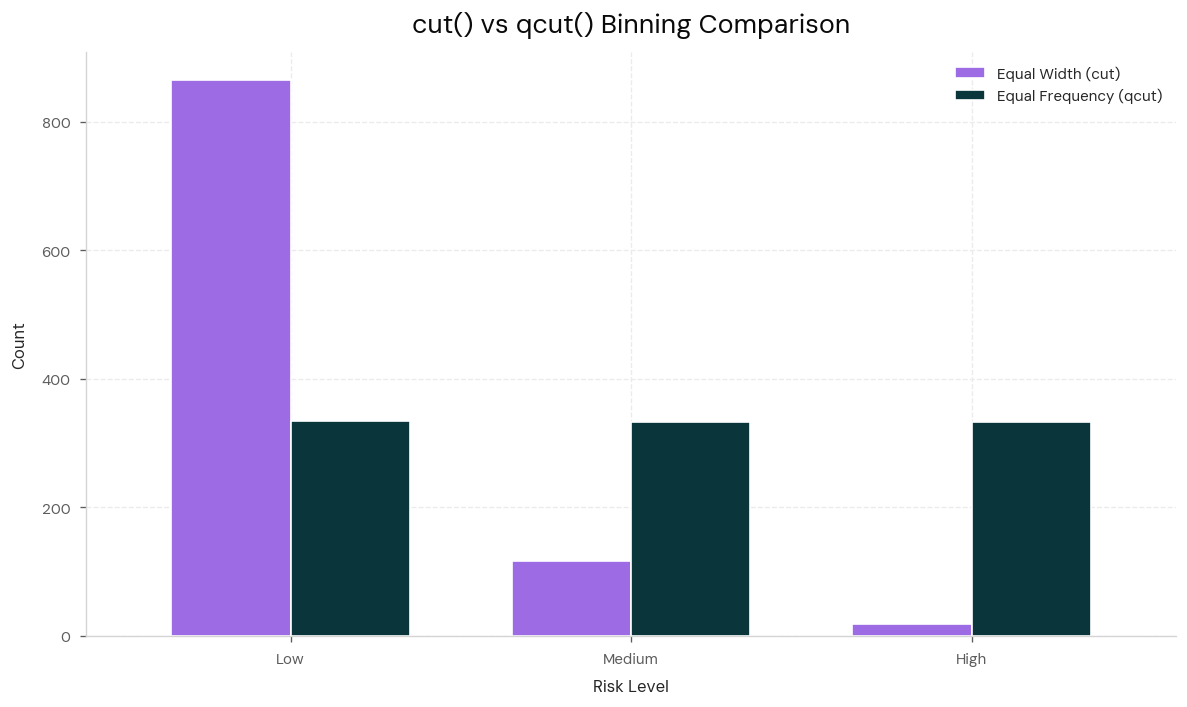

In [13]:
# Combine counts into one dataframe
comparison_df = pd.DataFrame({
    'cut': df['risk_cut'].value_counts().sort_index(),
    'qcut': df['risk_qcut'].value_counts().sort_index()
})

# Plot grouped bar chart
comparison_df.plot(
    kind='bar',
    figsize=(10, 6),
    color=[psu.palette['purple'][400], psu.palette['cyan'][900]],
    edgecolor='white',
    width=0.7
)

plt.title('cut() vs qcut() Binning Comparison', fontsize=16, fontweight='bold')
plt.xlabel('Risk Level')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.legend(['Equal Width (cut)', 'Equal Frequency (qcut)'])
plt.tight_layout()
plt.show()


### Plotting cut vs qcut bin descriptions 

Claude generated some code to plot the descriptions of cut and qcut bins. This is a useful way to visualize how the data is being binned and to understand the differences between the two methods.

In [14]:
# Get describe() for each binning method
cut_stats   = df.groupby('risk_cut')['credit_amount'].describe()
qcut_stats  = df.groupby('risk_qcut')['credit_amount'].describe()

# Rename index so we know which method each came from
cut_stats.index   = [f'{i} (cut)'  for i in cut_stats.index]
qcut_stats.index  = [f'{i} (qcut)' for i in qcut_stats.index]

# Stack them
comparison_df = pd.concat([cut_stats, qcut_stats]).sort_index()
comparison_df

,count,mean,std,min,25%,50%,75%,max
High (cut),19.00,14340.53,1547.73,12389.00,12862.50,14318.00,15274.50,18424.00
High (qcut),333.00,6345.29,2937.28,3378.00,3973.00,5511.00,7596.00,18424.00
Low (cut),865.00,2355.96,1380.11,250.00,1289.00,2002.00,3181.00,6304.00
Low (qcut),334.00,1107.99,322.98,250.00,876.00,1203.50,1365.50,1554.00
Medium (cut),116.00,8283.47,1626.35,6313.00,6991.00,7788.50,9278.50,12204.00
Medium (qcut),333.00,2366.98,486.91,1555.00,1941.00,2320.00,2759.00,3368.00


<Axes: >

[Text(0, 4, '2,356'),
 Text(0, 4, '2,002'),
 Text(0, 4, '1,289'),
 Text(0, 4, '3,181'),
 Text(0, 4, '1,380')]

[Text(0, 4, '1,108'),
 Text(0, 4, '1,204'),
 Text(0, 4, '876'),
 Text(0, 4, '1,366'),
 Text(0, 4, '323')]

Text(0.5, 1.0, 'Low Risk Band — cut() vs qcut() Statistics')

Text(0.5, 0, '')

Text(0, 0.5, 'Credit Amount (DM)')

(array([0, 1, 2, 3, 4]),
 [Text(0, 0, 'Mean'),
  Text(1, 0, 'Median'),
  Text(2, 0, 'Q1'),
  Text(3, 0, 'Q3'),
  Text(4, 0, 'Std Dev')])

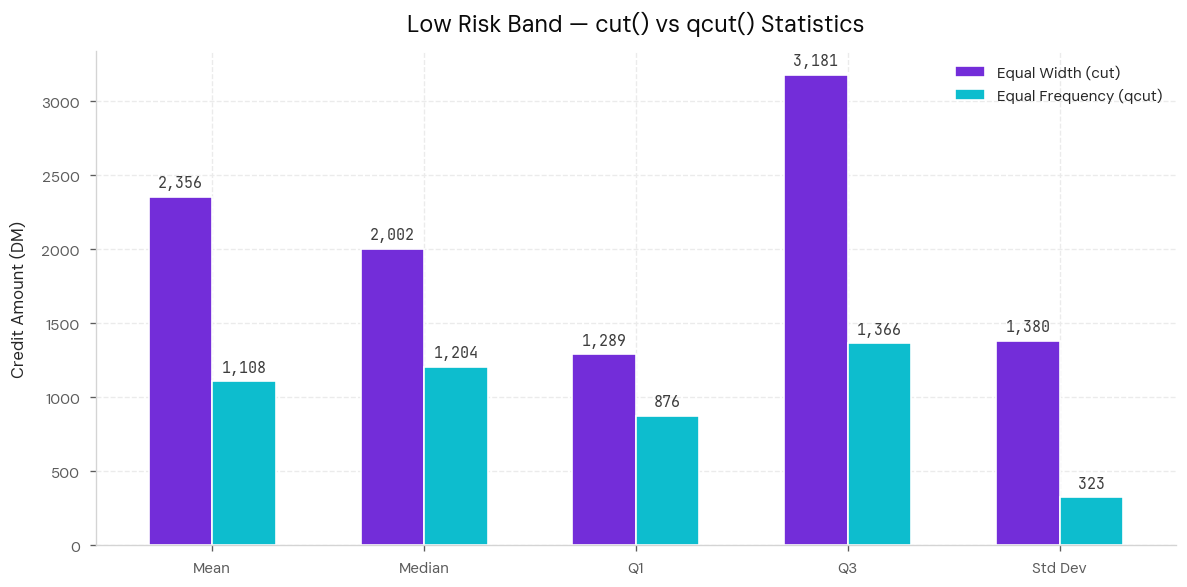

<Axes: >

[Text(0, 4, '8,283'),
 Text(0, 4, '7,788'),
 Text(0, 4, '6,991'),
 Text(0, 4, '9,278'),
 Text(0, 4, '1,626')]

[Text(0, 4, '2,367'),
 Text(0, 4, '2,320'),
 Text(0, 4, '1,941'),
 Text(0, 4, '2,759'),
 Text(0, 4, '487')]

Text(0.5, 1.0, 'Medium Risk Band — cut() vs qcut() Statistics')

Text(0.5, 0, '')

Text(0, 0.5, 'Credit Amount (DM)')

(array([0, 1, 2, 3, 4]),
 [Text(0, 0, 'Mean'),
  Text(1, 0, 'Median'),
  Text(2, 0, 'Q1'),
  Text(3, 0, 'Q3'),
  Text(4, 0, 'Std Dev')])

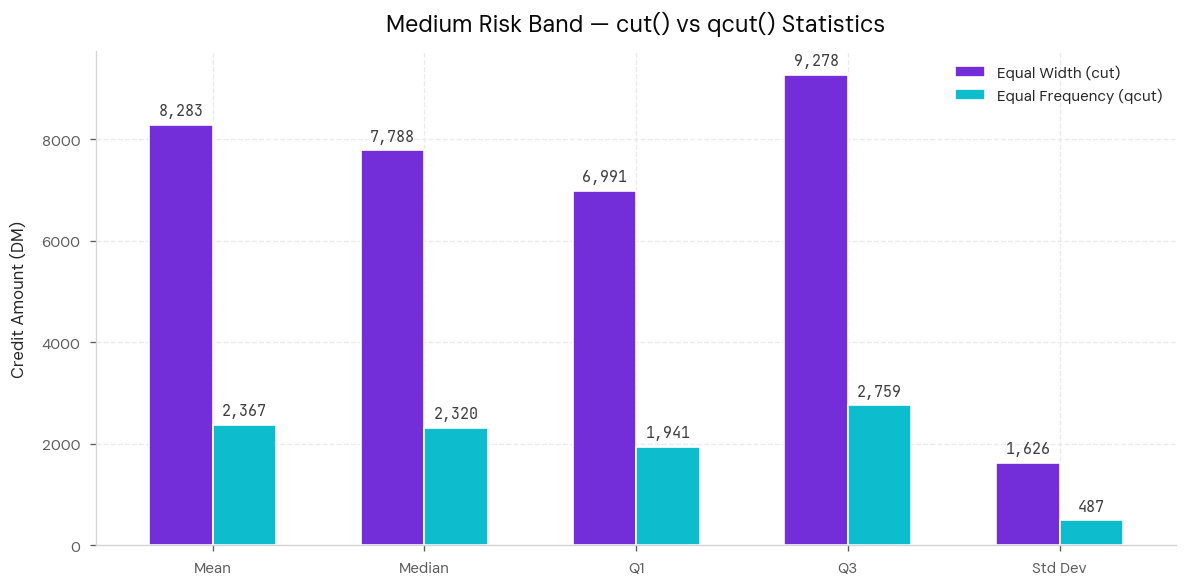

<Axes: >

[Text(0, 4, '14,341'),
 Text(0, 4, '14,318'),
 Text(0, 4, '12,862'),
 Text(0, 4, '15,274'),
 Text(0, 4, '1,548')]

[Text(0, 4, '6,345'),
 Text(0, 4, '5,511'),
 Text(0, 4, '3,973'),
 Text(0, 4, '7,596'),
 Text(0, 4, '2,937')]

Text(0.5, 1.0, 'High Risk Band — cut() vs qcut() Statistics')

Text(0.5, 0, '')

Text(0, 0.5, 'Credit Amount (DM)')

(array([0, 1, 2, 3, 4]),
 [Text(0, 0, 'Mean'),
  Text(1, 0, 'Median'),
  Text(2, 0, 'Q1'),
  Text(3, 0, 'Q3'),
  Text(4, 0, 'Std Dev')])

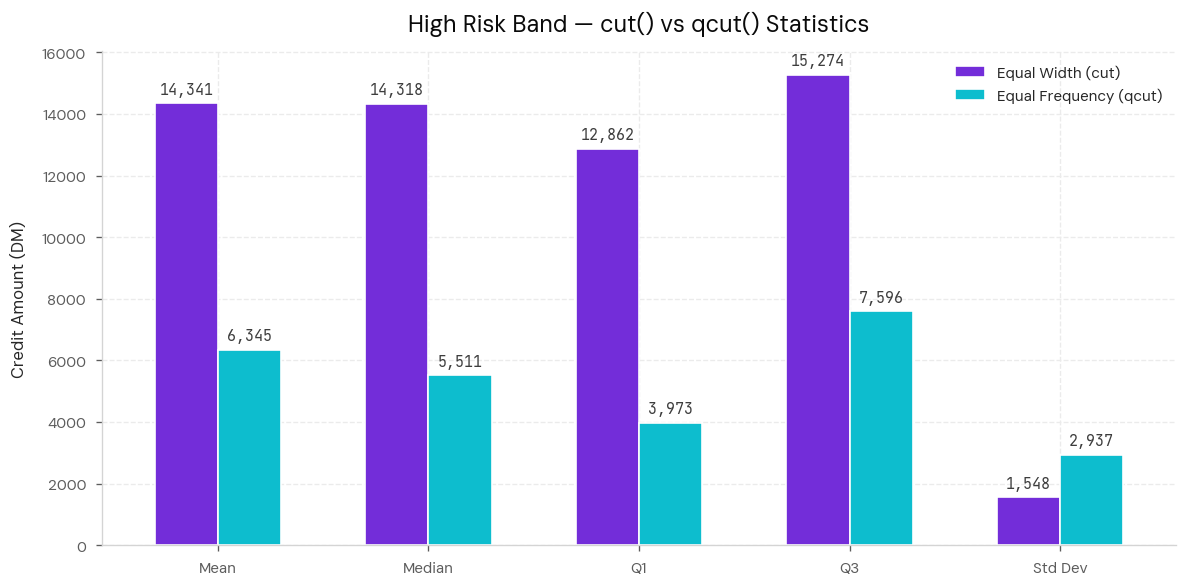

In [15]:
stats_to_plot = ['mean', '50%', '25%', '75%', 'std']
labels        = ['Mean', 'Median', 'Q1', 'Q3', 'Std Dev']
bins          = ['Low', 'Medium', 'High']

for bin_name in bins:
    cut_row  = cut_stats.loc[f'{bin_name} (cut)',  stats_to_plot]
    qcut_row = qcut_stats.loc[f'{bin_name} (qcut)', stats_to_plot]

    plot_df = pd.DataFrame({
        'cut':  cut_row.values,
        'qcut': qcut_row.values
    }, index=labels)

    plot_df.plot(
        kind='bar',
        figsize=(10, 5),
        color=[psu.p('purple', 500), psu.p('cyan', 600)],
        edgecolor='white',
        width=0.6
    )
    
    ax = plt.gca()
    for container in ax.containers:
        ax.bar_label(
            container,
            fmt='{:,.0f}',
            padding=4,
            fontsize=psu.sizes['mono'],
            fontfamily=psu.fonts['mono'],
            color=psu.palette['grey'][700]
    )

    plt.title(f'{bin_name} Risk Band — cut() vs qcut() Statistics',
              fontsize=14, fontweight='bold')
    plt.xlabel('')
    plt.ylabel('Credit Amount (DM)')
    plt.xticks(rotation=0)
    plt.legend(['Equal Width (cut)', 'Equal Frequency (qcut)'])
    plt.tight_layout()
    plt.show()

### Binary Data

Data that has only two possible values, often represented as 0 and 1. In credit risk: default status (defaulted, not defaulted), loan approval (approved, denied), presence of a co-signer (yes, no). These variables are typically modelled using logistic regression or other binary classification methods.

In [16]:
print(df['target'].value_counts())
print(df['target'].value_counts(normalize=True).round(3))

target
1    700
2    300
Name: count, dtype: int64
target
1   0.70
2   0.30
Name: proportion, dtype: float64


### Why Data Types Matter

Scikit-learn models require all inputs to be numeric. Passing a string column directly will throw an error. Understanding daxta types tells you: which columns need encoding, which need scaling, which can be used directly, and which might need binning. Getting this wrong causes silent errors worse than crashes — your model runs but learns garbage.

In [21]:
print(df.dtypes)

print('\nObject columns (need encoding):')
print(df.select_dtypes(include='object').columns.tolist())
print('\nNumeric columns (may need scaling):')
print(df.select_dtypes(include='number').columns.tolist())

checking_status            str
duration                 int64
credit_history             str
purpose                    str
credit_amount            int64
savings                    str
employment                 str
installment_rate         int64
personal_status            str
other_debtors              str
residence_since          int64
property                   str
age                      int64
other_installments         str
housing                    str
existing_credits         int64
job                        str
dependents               int64
telephone                  str
foreign_worker             str
target                   int64
risk_cut              category
risk_qcut             category
dtype: object

Object columns (need encoding):
['checking_status', 'credit_history', 'purpose', 'savings', 'employment', 'personal_status', 'other_debtors', 'property', 'other_installments', 'housing', 'job', 'telephone', 'foreign_worker']

Numeric columns (may need scaling):
['duration

## Part 2: Handling Missing Values

### Why Missing Values Exist in Credit Data

In real credit datasets, missing values are rarely random. A missing income field might mean self-employed. A missing savings balance might mean no savings account. Missing employment duration might mean unemployed. Understanding WHY data is missing is as important as deciding how to handle it — it often carries predictive signal itself.

In [ ]:
# Check missing values across entire dataframe

missing = df.isnull().sum()

missing_pct = (df.isnull().sum() / len(df) * 100).round(2)

print(pd.DataFrame({'Missing': missing, 'Pct': missing_pct}))

                    Missing  Pct
checking_status     0       0.00
duration            0       0.00
credit_history      0       0.00
purpose             0       0.00
credit_amount       0       0.00
savings             0       0.00
employment          0       0.00
installment_rate    0       0.00
personal_status     0       0.00
other_debtors       0       0.00
residence_since     0       0.00
property            0       0.00
age                 0       0.00
other_installments  0       0.00
housing             0       0.00
existing_credits    0       0.00
job                 0       0.00
dependents          0       0.00
telephone           0       0.00
foreign_worker      0       0.00
target              0       0.00
risk_cut            0       0.00
risk_qcut           0       0.00


### Types of Missingness

MCAR (Missing Completely At Random) — the missingness has no relationship to any variable. Rare in credit data. MAR (Missing At Random) — missingness is related to other observed variables but not the missing value itself. MNAR (Missing Not At Random) — the missingness is related to the missing value itself, e.g. high earners refusing to disclose income. MNAR is the most dangerous for models and hardest to handle.

## Results

### Findings & Next Steps
- Finding 1
- Finding 2
- Next step 1

In [17]:
print(df.select_dtypes(include='number').describe().round(2))

       duration  credit_amount  installment_rate  residence_since  age     \
count 1000.00    1000.00       1000.00           1000.00          1000.00   
mean    20.90    3271.26          2.97              2.84            35.55   
std     12.06    2822.74          1.12              1.10            11.38   
min      4.00     250.00          1.00              1.00            19.00   
25%     12.00    1365.50          2.00              2.00            27.00   
50%     18.00    2319.50          3.00              3.00            33.00   
75%     24.00    3972.25          4.00              4.00            42.00   
max     72.00   18424.00          4.00              4.00            75.00   

       existing_credits  dependents  target  
count 1000.00           1000.00     1000.00  
mean     1.41              1.16        1.30  
std      0.58              0.36        0.46  
min      1.00              1.00        1.00  
25%      1.00              1.00        1.00  
50%      1.00              1.0